# Phase 1 — Data Preprocessing & Cleaning

We start by loading the data and doing all the cleaning needed before modelling.

The report and notebooks follow the data science lifecycle: Phase 1 covers data cleaning and preprocessing, Phase 2 applies unsupervised learning (PCA and clustering) to explore the structure of the portfolio, and Phase 3 builds the supervised prediction model for FREQ, CM, and the final CHARGE.

The key challenge is that missing values are not random. They come in blocks: a whole set of columns is missing together for the same contracts. This is a **MNAR** pattern (Missing Not At Random). The absence of data is itself informative. It likely means those contracts were entered into an older IT system that did not record certain fields.

Following the missing data decision tree from the lecture:

- Pattern is **MNAR** and domain knowledge is available (we know it is a legacy data issue)
- Nature of missingness is **Systematic**, so the recommended method is **Pattern Mixture Models**

A full pattern mixture model estimates a separate distribution for each missing pattern. That would be expensive here. Instead, we use a simpler approximation: we **extract the missingness pattern into a single binary flag** (`meta_missing_legacy_data = 1` for legacy contracts), then drop the heavily sparse columns. The key signal (which contracts belong to the old system) is preserved without the full complexity. This is a standard simplification of the pattern mixture idea.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

X_train = pd.read_csv("train_input_Z61KlZo.csv", index_col=0)
X_test  = pd.read_csv("test_input_5qJzHrr.csv", index_col=0)
y_train = pd.read_csv("train_output_DzPxaPY.csv", index_col=0)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | X_test: {X_test.shape}")


X_train: (383610, 373) | y_train: (383610, 4) | X_test: (95852, 373)


### 1.1 Core cleaning function

Both Phase 2 and Phase 3 share the same base cleaning logic in `_core_clean()`. The two phases differ only in their **column drop threshold**:

- Phase 2 (PCA): strict 50% threshold. PCA needs dense, well-filled columns.
- Phase 3 (XGBoost): loose 95% threshold. At each split, XGBoost tries both directions for missing values and keeps whichever reduces the loss more, so sparse columns need no imputation.

The MNAR flag is computed on columns missing between 56% and 59%, capturing exactly the legacy block. Columns above the phase-specific drop threshold are then removed, but the flag remains.

Some columns store ranges like `"10-20"` or text codes like `"ANNEE5"` instead of plain numbers. We need to convert those to numbers for the model to use them. We do this only for columns where we know the format (e.g. `DISTANCE_`, `ALTITUDE_`, `AN_EXERC`). We avoid applying any broad automatic conversion because it would silently corrupt columns that just happen to start with a digit.


In [2]:
def _core_clean(X):
    X = X.copy()

    # replace all known placeholders with proper NaN
    X = X.replace(['NC', 'ND', '?', 'i', '', ' ', 'absence de surface'], np.nan)

    # top-coding: '7000+' means the value was censored at 7000
    # we use 7500 as a midpoint and add a binary flag so the model knows it was censored
    for col in ['SURFACE4', 'SURFACE6']:
        if col in X.columns:
            X[f'{col}_is_topcoded'] = (X[col].astype(str) == '7000+').astype(int)
            X[col] = pd.to_numeric(
                X[col].astype(str).str.replace('7000+', '7500', regex=False),
                errors='coerce')

    # specific ordinal extractions for known columns only
    if 'AN_EXERC' in X.columns:
        X['AN_EXERC'] = pd.to_numeric(
            X['AN_EXERC'].astype(str).str.replace('ANNEE', '', regex=False),
            errors='coerce')
    if 'INDEM2' in X.columns:
        X['INDEM2'] = pd.to_numeric(
            X['INDEM2'].astype(str).str.replace('CLASS', '', regex=False),
            errors='coerce')

    # targeted prefix extraction for bin columns only (distance / altitude / proportion / household)
    # these store ranges like "10-20" and we want the lower bound
    bin_cols = [c for c in X.columns
                if c.startswith(('DISTANCE_', 'PROPORTION_', 'ALTITUDE_')) or 'MEN_COLL' in c]
    for col in bin_cols:
        if X[col].dtype == 'object':
            X[col] = X[col].astype(str).str.extract(r'^(\d+)').astype(float)

    # binary O/N flags: map to 0/1 explicitly
    # cast to object first so category columns don't raise a TypeError
    on_flags = (['ADOSS', 'INDEM1']
                + [f'DEROG{i}' for i in range(1, 17)]
                + [f'KAPITAL{i}' for i in range(34, 44)])
    for col in on_flags:
        if col in X.columns:
            X[col] = X[col].astype(object).map({'O': 1, 'N': 0, 'o': 1, 'n': 0})

    # binary 1/2 flags: recode to 0/1
    for col in ['TYPERS', 'CARACT2']:
        if col in X.columns:
            X[col] = X[col].astype(object).map({1: 0, 2: 1, '1': 0, '2': 1})

    # column-specific fixes
    if 'FRCH2' in X.columns:
        X['FRCH2'] = pd.to_numeric(X['FRCH2'].astype(object).replace('A', 99), errors='coerce')
    if 'FRCH1' in X.columns:
        X['FRCH1'] = pd.to_numeric(X['FRCH1'], errors='coerce')
    if 'CARACT4' in X.columns:
        X['CARACT4'] = X['CARACT4'].astype(object).map({
            'absence de surface': 0, 'Surface de moins d': 1,
            'Surface entre 501':  2, 'Surface entre 1001': 3,
            'Surface entre 1501': 4, 'Surface de plus de': 5})
    if 'COEFASS' in X.columns:
        X['COEFASS'] = pd.to_numeric(
            X['COEFASS'].astype(object).map(
                {'01-Oct': 10, 'Nov-20': 20, '21-30': 30, '31-40': 40, '41-50': 50}
            ).fillna(X['COEFASS']),
            errors='coerce')

    # cast remaining object columns to category for XGBoost
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].astype('category')

    return X


In [3]:
def load_and_clean(X, y=None, drop_threshold=0.56):
    """Will have MNAR flag for columns with missing 56 to 59%"""
    X = _core_clean(X)

    # MNAR flag always computed at the same threshold — always refers to the same legacy block
    missing_pct  = X.isnull().mean()
    high_missing = missing_pct[(missing_pct > drop_threshold) & (missing_pct < drop_threshold+0.03)].index
    if len(high_missing) > 0:
        X['meta_missing_legacy_data'] = (
            X[high_missing].isnull().mean(axis=1) > 0.5).astype(int)

    # drop columns above the phase-specific threshold
    cols_to_drop = missing_pct[missing_pct > drop_threshold].index
    X = X.drop(columns=cols_to_drop, errors='ignore')

    if y is not None:
        # 6 contracts have negative CHARGE in the raw CSV (possible refunds or corrections)
        # clipping to zero before training and evaluation
        if hasattr(y, 'copy'):
            y = y.copy()
            if 'CHARGE' in y.columns:
                y['CHARGE'] = y['CHARGE'].clip(lower=0)
        return X, y
    return X


### 1.2 Missingness analysis

Before using the flag, we want to show that the missing values actually come in a block, all on the same rows. If the missingness correlation is high across those columns, that confirms the MNAR structure and justifies using a single flag to represent all of it.


In [4]:
missing_pct = X_train.isnull().mean().sort_values(ascending=False)
high_missing_cols = missing_pct[missing_pct > 0.5].index

if len(high_missing_cols) > 1:
    miss_corr = X_train[high_missing_cols].isnull().astype(int).corr()
    mean_off_diag = miss_corr.where(~np.eye(len(miss_corr), dtype=bool)).stack().mean()
    print(f"Columns missing >50%: {len(high_missing_cols)}")
    print(f"Mean pairwise missingness correlation: {mean_off_diag:.3f}")
    print("High correlation confirms a single systematic block (MNAR), not random dropout.")


Columns missing >50%: 183
Mean pairwise missingness correlation: 0.923
High correlation confirms a single systematic block (MNAR), not random dropout.


**Analysis:** when the mean pairwise correlation is close to 1.0 like here, it means all those columns are missing on the same rows. That confirms the block is structural (old IT system) and not random dropout. This justifies using a single binary flag to represent the whole missing pattern.


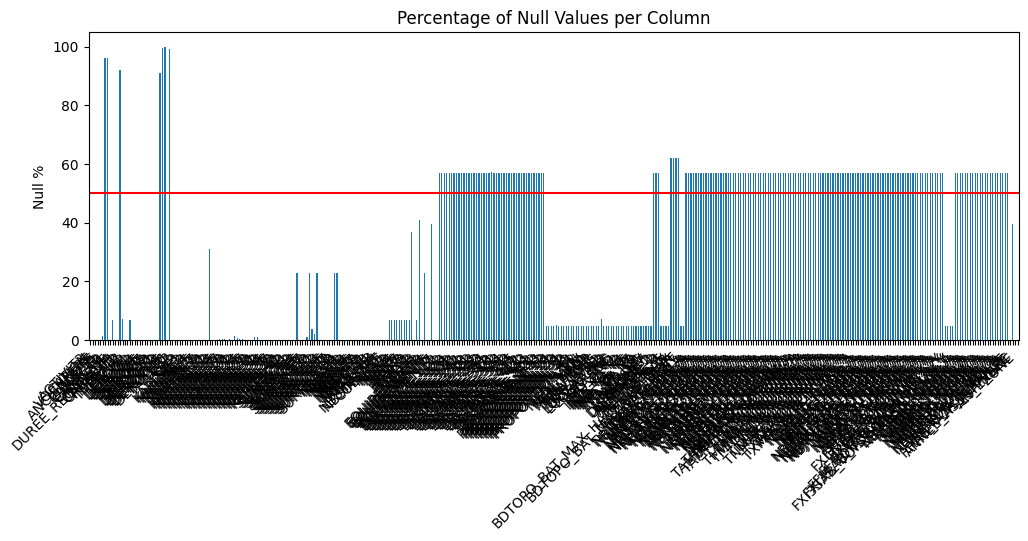

In [5]:
# Visualize the Null % per Columns

def visualize_null(df):
    null_percentage = df.isnull().mean() * 100
    plt.figure(figsize=(12, 4))
    null_percentage.plot(kind='bar')
    plt.axhline(50, color='r')               # 50% of null values
    plt.title('Percentage of Null Values per Column')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Null %')
    plt.show()

visualize_null(X_train)

The bar chart above shows the null percentage per column without sorting, which helps spot the block visually. The plot below sorts columns by missingness and adds the 50% threshold line to make the step clearer.


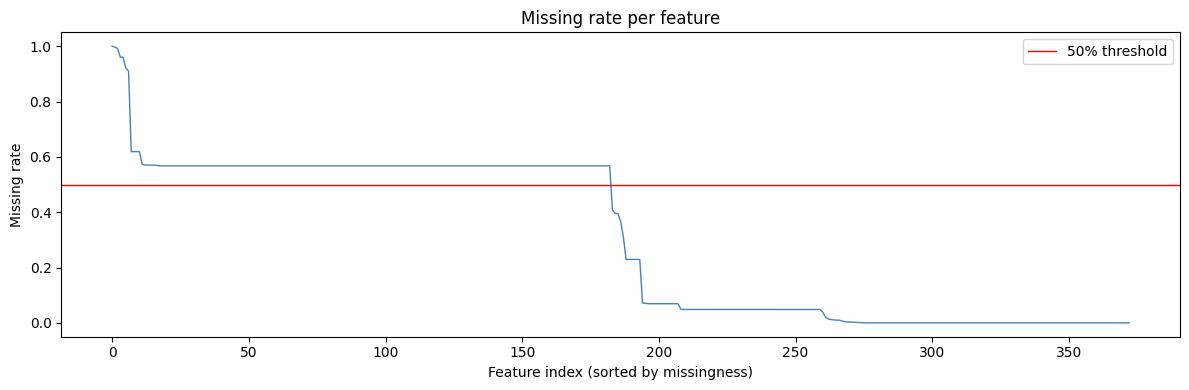

In [6]:
# plot the missing rate for every column, sorted descending
# the red line at 50% is our cut-off for the MNAR block
fig, ax = plt.subplots(figsize=(12, 4))
missing_sorted = missing_pct.sort_values(ascending=False)
ax.plot(missing_sorted.values, linewidth=1, color='steelblue')
ax.axhline(y=0.5, color='red', linestyle='-', linewidth=1, label='50% threshold')
ax.set_xlabel('Feature index (sorted by missingness)')
ax.set_ylabel('Missing rate')
ax.set_title('Missing rate per feature')
ax.legend()
plt.tight_layout()
plt.show()


**Analysis:** the plot shows a clear step: most features have zero or very low missingness, then a group of columns all jump to around the same high missing rate. That step is the legacy block. The flag captures exactly those columns (56–59% missing range).


# Phase 2 — Unsupervised Learning (Insights)

We use the strict 50% threshold here. PCA works best on well-filled columns, so we drop anything with more than half its values missing.

One technical note: sklearn's `SimpleImputer` and our custom `FrequencyEncoder` expect plain `object` dtype for categorical columns, not the pandas `category` dtype. So we convert category columns back to object before building the Phase 2 pipeline. The `category` dtype is only needed for XGBoost in Phase 3.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin


## 2.1 Pipeline

In [8]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # X may arrive as a numpy array after SimpleImputer, so we handle both cases
        if hasattr(X, 'columns'):
            self.feature_names_in_ = list(X.columns)
            data = X
        else:
            self.feature_names_in_ = [str(i) for i in range(X.shape[1])]
            data = pd.DataFrame(X, columns=self.feature_names_in_)
        # for each column, compute how often each value appears (as a fraction)
        self.freq_maps_ = {col: pd.Series(data[col]).value_counts(normalize=True)
                           for col in self.feature_names_in_}
        return self

    def transform(self, X):
        if hasattr(X, 'columns'):
            data = X.copy()
        else:
            data = pd.DataFrame(X, columns=self.feature_names_in_)
        # replace each category with its frequency — unknown values get 0
        for col in self.feature_names_in_:
            data[col] = data[col].map(self.freq_maps_.get(col)).fillna(0)
        return data.values

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)


In [9]:
def build_phase2_pipeline(X):
    missing_pct = X.isnull().mean()

    # split columns into 3 buckets based on how much data is missing
    cols_0    = missing_pct[missing_pct == 0].index.tolist()           # fully complete
    cols_5_15 = missing_pct[(missing_pct > 0) & (missing_pct <= 0.15)].index.tolist()  # a little missing
    cols_gt15 = missing_pct[missing_pct > 0.15].index.tolist()         # a lot missing

    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

    # intersect the two splits: missingness bucket x data type
    num_0    = [c for c in cols_0    if c in num_cols]
    cat_0    = [c for c in cols_0    if c in cat_cols]
    num_5_15 = [c for c in cols_5_15 if c in num_cols]
    cat_5_15 = [c for c in cols_5_15 if c in cat_cols]
    num_gt15 = [c for c in cols_gt15 if c in num_cols]
    cat_gt15 = [c for c in cols_gt15 if c in cat_cols]

    preprocessor = ColumnTransformer(transformers=[
        ('num_0',    StandardScaler(), num_0),
        ('cat_0',    Pipeline([('enc', FrequencyEncoder()), ('scl', StandardScaler())]), cat_0),
        ('num_5_15', Pipeline([('imp', SimpleImputer(strategy='median')),
                                ('scl', StandardScaler())]), num_5_15),
        ('cat_5_15', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                ('enc', FrequencyEncoder()),
                                ('scl', StandardScaler())]), cat_5_15),
        ('num_gt15', Pipeline([('imp', SimpleImputer(strategy='median')),
                                ('scl', StandardScaler())]), num_gt15),
        ('cat_gt15', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                ('enc', FrequencyEncoder()),
                                ('scl', StandardScaler())]), cat_gt15),
    ])
    return preprocessor


In [10]:
X_clean_phase_2, y_clean_phase_2 = load_and_clean(X_train, y_train, drop_threshold=0.5)

# converting category columns back to object — sklearn can't handle the category dtype
for col in X_clean_phase_2.select_dtypes(include=['category']).columns:
    X_clean_phase_2[col] = X_clean_phase_2[col].astype(object)

preprocessor_pca = build_phase2_pipeline(X_clean_phase_2)
X_train_pca_ready = preprocessor_pca.fit_transform(X_clean_phase_2)

total_nans = np.isnan(X_train_pca_ready).sum()
print(f"NaNs remaining: {total_nans} | Shape: {X_train_pca_ready.shape}")


NaNs remaining: 0 | Shape: (383610, 190)


## 2.2 PCA

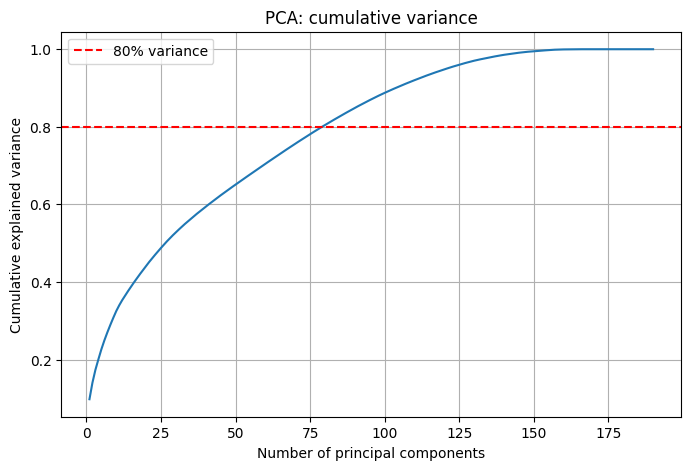

In [11]:
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_train_pca_ready)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: cumulative variance')
plt.legend()
plt.grid(True)
plt.show()


**Observations:** the curve shows how many components are needed to explain 80% of the variance in the data. A steep initial rise means a few components capture most of the signal. The 80% threshold is a practical cutoff we use later for clustering.


In [12]:
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"PCs needed for 80% variance: {n_components_80}")


PCs needed for 80% variance: 79


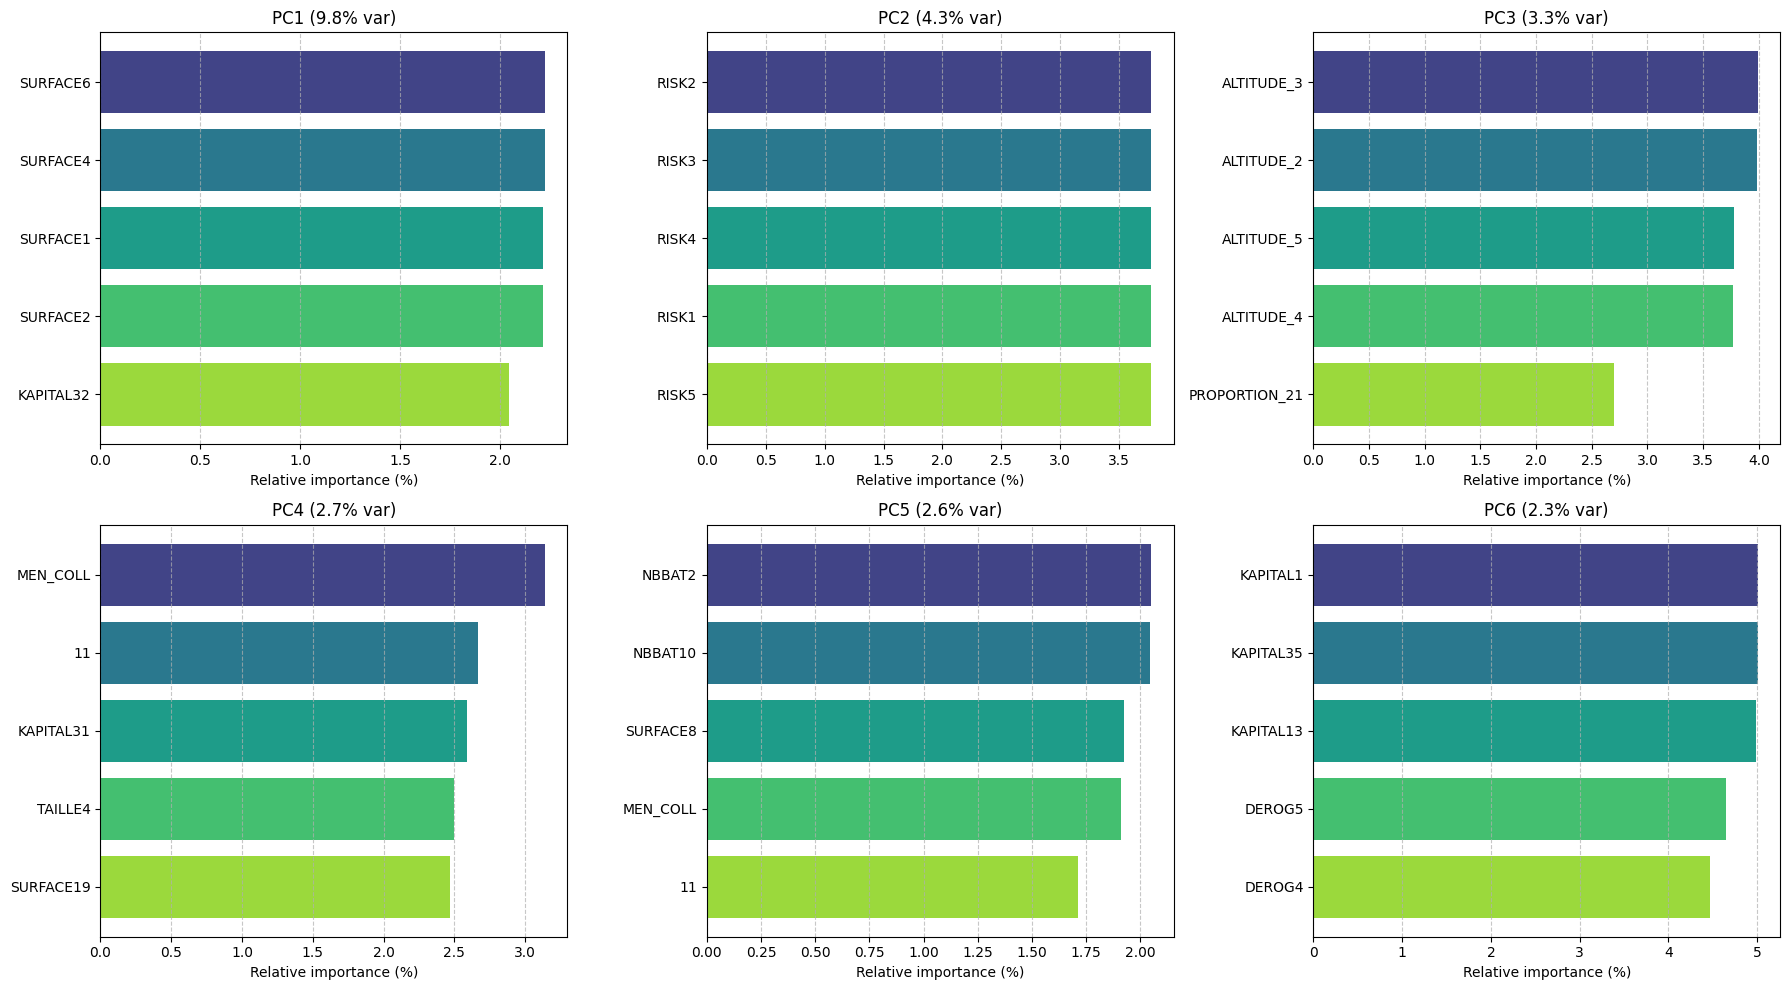

Principal components summary:
    Variance (%)              Top 1              Top 2              Top 3  \
PC1        9.77%    (2.2%) SURFACE6    (2.2%) SURFACE4    (2.2%) SURFACE1   
PC2        4.26%       (3.8%) RISK2       (3.8%) RISK3       (3.8%) RISK4   
PC3        3.33%  (4.0%) ALTITUDE_3  (4.0%) ALTITUDE_2  (3.8%) ALTITUDE_5   
PC4        2.71%    (3.1%) MEN_COLL          (2.7%) 11   (2.6%) KAPITAL31   
PC5        2.59%      (2.1%) NBBAT2     (2.0%) NBBAT10    (1.9%) SURFACE8   
PC6        2.28%    (5.0%) KAPITAL1   (5.0%) KAPITAL35   (5.0%) KAPITAL13   

                 Top 4                Top 5  
PC1    (2.2%) SURFACE2     (2.0%) KAPITAL32  
PC2       (3.8%) RISK1         (3.8%) RISK5  
PC3  (3.8%) ALTITUDE_4  (2.7%) PROPORTION_2  
PC4     (2.5%) TAILLE4     (2.5%) SURFACE19  
PC5    (1.9%) MEN_COLL            (1.7%) 11  
PC6      (4.6%) DEROG5        (4.5%) DEROG4  


In [13]:
raw_features   = preprocessor_pca.get_feature_names_out()
clean_features = np.array([f.split('__')[-1] for f in raw_features])  # strip the pipeline prefix

n_pcs      = 6
top_n      = 5
table_data = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = plt.cm.viridis([0.85, 0.7, 0.55, 0.4, 0.2])        # one colour per top feature

for i in range(n_pcs):
    pc_var      = pca.explained_variance_ratio_[i] * 100
    abs_load    = np.abs(pca.components_[i])
    rel_imp     = (abs_load / np.sum(abs_load)) * 100          # normalise to sum to 100%
    top_indices = np.argsort(rel_imp)[::-1][:top_n]
    top_vals    = rel_imp[top_indices]
    top_names   = clean_features[top_indices]

    row = {'Variance (%)': f"{pc_var:.2f}%"}
    for rank, (name, val) in enumerate(zip(top_names, top_vals)):
        row[f'Top {rank+1}'] = f"({val:.1f}%) {name[:12]}"
    table_data.append(row)

    axes[i].barh(top_names[::-1], top_vals[::-1], color=colors)  # one colour per bar
    axes[i].set_title(f'PC{i+1} ({pc_var:.1f}% var)')
    axes[i].set_xlabel('Relative importance (%)')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Principal components summary:")
print(pd.DataFrame(table_data, index=[f'PC{i+1}' for i in range(n_pcs)]))


**Observations:**

- **PC1 (Physical scale):** driven by surface areas and primary capital. It captures the overall size of the farm.
- **PC2 (Risk profile):** isolates the actuarial risk factors (RISK1 to RISK5).
- **PC3 (Topography):** dominated by altitude features. It groups farms by geography and environment.
- **PC4 (Socio-demographics):** household and membership variables (MEN_* and LOG_SOC).
- **PC5 and PC6 (Assets and exceptions):** granular infrastructure (NBBAT) and pricing exceptions (DEROG).

A farm's fire risk is not one-dimensional. The PCA tells us it breaks down into at least six independent axes: how big the farm is, how risky it is rated, where it sits geographically, who owns it, how many buildings are on it, and whether it has special pricing rules. A large farm in a high-altitude zone with many buildings is a fundamentally different risk from a small farm in a flat area — and the model needs all six dimensions to price them correctly.


## 2.3 Clustering

We cluster on the PCA-reduced space (the components covering 80% of variance). Using all 373 raw features would let noise dominate the distance calculations between farms.


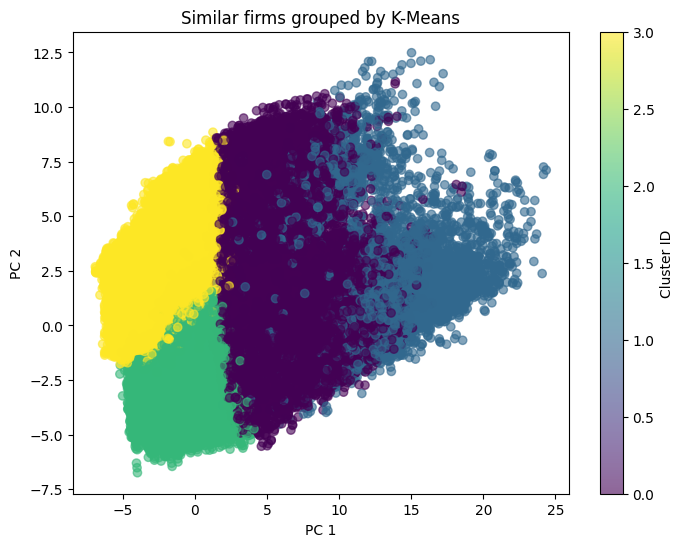

In [14]:
X_pca_df = pd.DataFrame(X_pca[:, :n_components_80])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_df)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Similar firms grouped by K-Means')
plt.colorbar(scatter, label='Cluster ID')
plt.show()


**Observations:** the scatter shows how the 4 clusters sit in the first two principal component dimensions. Well-separated clusters in PC1/PC2 space mean the grouping captures a real physical difference between farms. That means it reflects farm size and risk profile, not just random variation.


In [15]:
analysis_df = y_clean_phase_2.copy()
analysis_df['Cluster'] = cluster_labels
cluster_profile = analysis_df.groupby('Cluster')[['FREQ', 'CM', 'CHARGE']].mean()

print("Average risk profile by cluster:")
print(cluster_profile)


Average risk profile by cluster:
             FREQ          CM      CHARGE
Cluster                                  
0        0.024066  421.249175  430.008232
1        0.057183  763.276039  768.773662
2        0.007991   95.155353   98.120265
3        0.006661   81.428017   82.276294


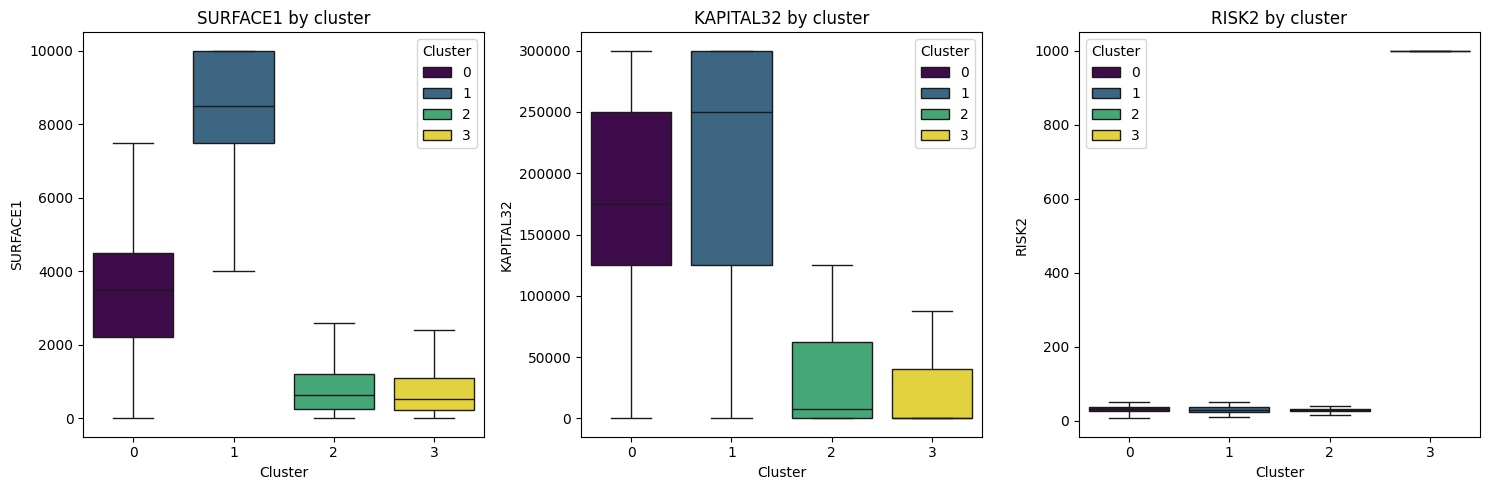

In [16]:
eval_df = X_clean_phase_2.copy()
eval_df['Cluster'] = cluster_labels
eval_df['FREQ']    = y_clean_phase_2['FREQ']
eval_df['CM']      = y_clean_phase_2['CM']

top_features = ['SURFACE1', 'KAPITAL32', 'RISK2']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, top_features):
    sns.boxplot(x='Cluster', y=feat, data=eval_df, ax=ax,
                palette='viridis', hue='Cluster', showfliers=False)
    ax.set_title(f'{feat} by cluster')
plt.tight_layout()
plt.show()


**Observations:** each cluster has a distinct distribution for farm size (SURFACE1), insured capital (KAPITAL32), and risk score (RISK2). That confirms the clusters are not arbitrary. They correspond to meaningfully different types of farms.


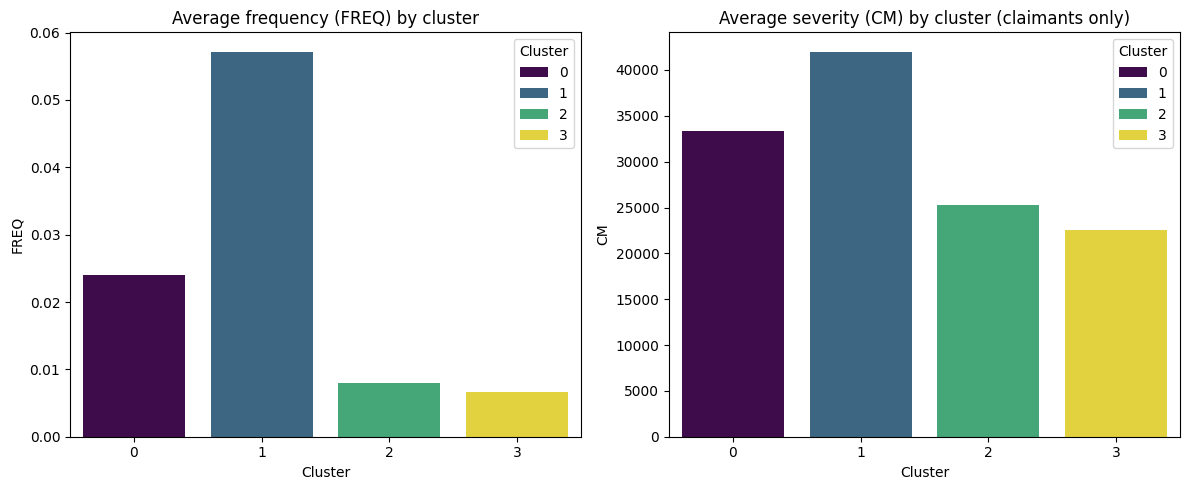

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Cluster', y='FREQ', data=eval_df, ax=axes[0],
            palette='viridis', hue='Cluster', errorbar=None)
axes[0].set_title('Average frequency (FREQ) by cluster')

sns.barplot(x='Cluster', y='CM', data=eval_df[eval_df['CM'] > 0], ax=axes[1],
            palette='viridis', hue='Cluster', errorbar=None)
axes[1].set_title('Average severity (CM) by cluster (claimants only)')
plt.tight_layout()
plt.show()


**Observations:** the clusters separate not just physically but also in terms of insurance outcomes. Some clusters have higher claim frequency, others have higher average cost when a claim does occur. This is useful context for Phase 3. We expect the FREQ and CM models to implicitly learn these groupings through the same features.


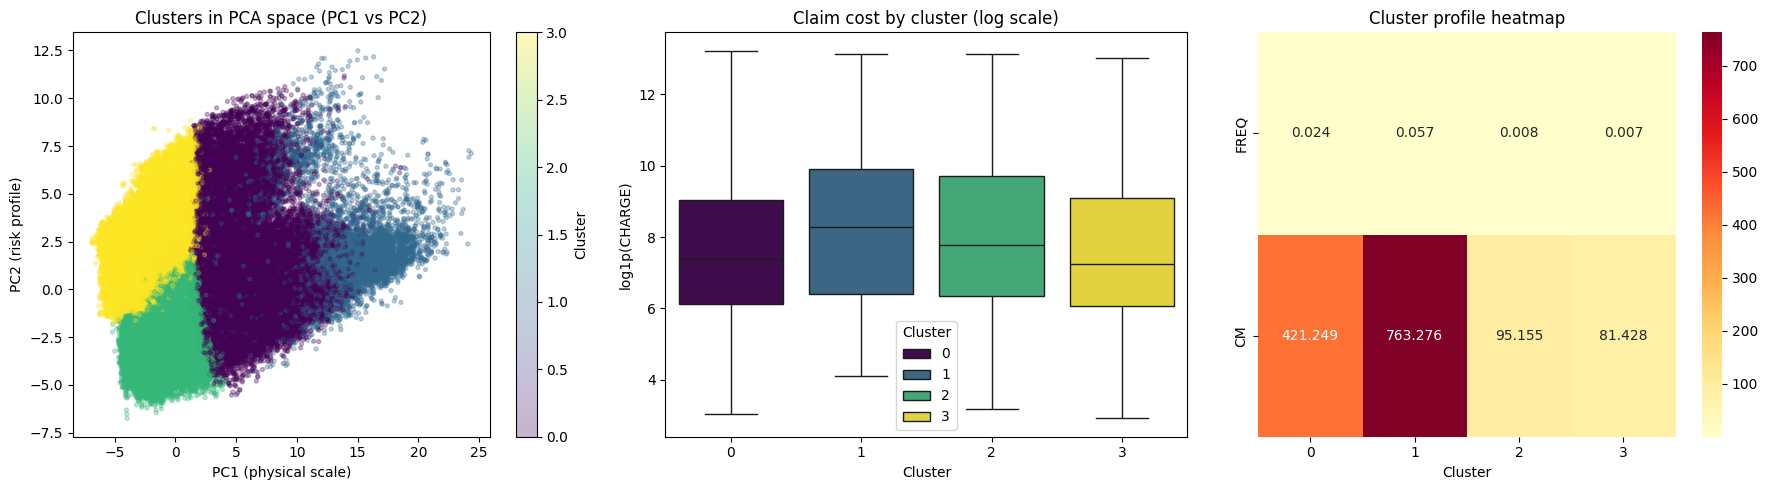

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=cluster_labels, cmap='viridis', alpha=0.3, s=8)
axes[0].set_title("Clusters in PCA space (PC1 vs PC2)")
axes[0].set_xlabel("PC1 (physical scale)")
axes[0].set_ylabel("PC2 (risk profile)")
plt.colorbar(scatter, ax=axes[0], label='Cluster')

claim_df = eval_df.copy()
claim_df['CHARGE'] = y_clean_phase_2['CHARGE']
claim_df = claim_df[claim_df['CHARGE'] > 0]
sns.boxplot(x='Cluster', y=np.log1p(claim_df['CHARGE']), data=claim_df,
            palette='viridis', hue='Cluster', showfliers=False, ax=axes[1])
axes[1].set_title("Claim cost by cluster (log scale)")
axes[1].set_ylabel("log1p(CHARGE)")

heatmap_data = cluster_profile[['FREQ', 'CM']].T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title("Cluster profile heatmap")

plt.tight_layout()
plt.show()


**Observations:** the PCA scatter confirms the clusters are geometrically coherent, not scattered noise. The claim cost boxplot (log scale) shows that some clusters are systematically more expensive when fires do occur. The heatmap gives a quick summary of the full business profile of each group:  
- Cluster 3 represents a small but dangerous segment: it has both the highest claim frequency (0.057 claims/year) and the highest average claim cost (763€), making it the dominant driver of total portfolio's risk.  
- Cluster 0 also shows high severity (424€) with moderate frequency. 
- Clusters 1 and 2 account for the majority of contracts but contribute little to total losses. This confirms that the portfolio is highly heterogeneous, and that a flat pricing approach would massively underprice the high-risk segment.

# Phase 3 — Supervised Learning (Prediction)

We build a **pure premium model** to predict the expected insurance cost per contract. The target is `CHARGE = FREQ x CM x ANNEE_ASSURANCE`, where:

- `FREQ` = claim frequency (number of claims per year)
- `CM` = average cost per claim (severity)
- `ANNEE_ASSURANCE` = contract exposure in years

We model FREQ and CM separately, then multiply at the very end. This **two-part decomposition** was imposed by the instructions. It avoids mixing up two very different questions: how often fires happen, and how costly they are when they do.


In [19]:
import xgboost as xgb
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, median_absolute_error, mean_absolute_error


**Why predict CHARGE as FREQ x CM?**

If we predict CHARGE directly, the model would be dominated by squared errors on rare catastrophic fires (e.g. 500k euros) that are fundamentally unpredictable. By splitting into two sub-models, each one learns a simpler and better-posed problem:

- FREQ is a count rate, so a **Poisson objective** is the natural fit.
- CM is a positive, right-skewed cost, so a **Gamma objective** is the natural fit.

A flat scatter on actual vs predicted is not a model failure. We predict an expected premium (a small mean across many contracts), not the outcome of a specific random fire event.


## 3.1 Feature engineering and cleaning

Phase 3 uses the same `load_and_clean` function with a **95% drop threshold**. XGBoost handles sparse columns well, so we keep more features than Phase 2 did.

Some groups of related columns (e.g. all the SURFACE columns, all the RISK columns) each describe one thing but are split across many features. We want to turn those groups into a single number the model can use directly. So we sum or average them into new columns:

- `TOTAL_SURFACE` and `TOTAL_CAPITAL`: total exposed value across all sub-categories
- `CAPITAL_PER_M2`: how much capital is packed per unit of surface (a fire-load intensity indicator)
- `RISK_SUM` and `RISK_MEAN`: overall risk score across all risk sub-scores
- `PREV_SUM`: total number of prevention measures in place
- `TOTAL_BUILDINGS`: total number of insured structures


In [20]:
def add_domain_aggregates(X):
    X = X.copy()

    # collect all columns that belong to each group
    surface_cols = [c for c in X.columns if c.startswith('SURFACE') and not c.endswith('_is_topcoded')]
    capital_cols = [c for c in X.columns if c.startswith('CAPITAL')]
    risk_cols    = [c for c in X.columns if c.startswith('RISK')]
    prev_cols    = [c for c in X.columns if c.startswith('PREV')]
    bat_cols     = [c for c in X.columns if c.startswith('NBBAT')]

    if surface_cols:
        X['TOTAL_SURFACE']   = X[surface_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
    if capital_cols:
        X['TOTAL_CAPITAL']   = X[capital_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
    if surface_cols and capital_cols:
        X['CAPITAL_PER_M2']  = X['TOTAL_CAPITAL'] / (X['TOTAL_SURFACE'] + 1)  # +1 avoids division by zero
    if risk_cols:
        X['RISK_SUM']        = X[risk_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
        X['RISK_MEAN']       = X[risk_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True)
    if prev_cols:
        X['PREV_SUM']        = X[prev_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
    if bat_cols:
        X['TOTAL_BUILDINGS'] = X[bat_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1, skipna=True)
    return X


def load_and_clean_phase3(X, y=None, threshold=0.95):
    X = load_and_clean(X, drop_threshold=threshold)  # base cleaning + MNAR flag
    X = add_domain_aggregates(X)                     # add the group-level summary columns
    if y is not None:
        return X, y
    return X


X_clean_3, y_clean_3 = load_and_clean_phase3(X_train, y_train)
print(f"Phase 3 shape: {X_clean_3.shape}")
print(f"Engineered cols present: {[c for c in ['TOTAL_SURFACE','TOTAL_CAPITAL','CAPITAL_PER_M2','RISK_SUM','TOTAL_BUILDINGS'] if c in X_clean_3.columns]}")


Phase 3 shape: (383610, 372)
Engineered cols present: ['TOTAL_SURFACE', 'RISK_SUM', 'TOTAL_BUILDINGS']


## 3.2 Hyperparameter tuning

XGBoost has many settings (called hyperparameters) that control how the trees are built. The defaults are fine, but tuning them can improve performance. The idea is to try many different combinations and keep the one that performs best in cross-validation.

We fix the FREQ model parameters based on earlier experiments (those settings already gave a test score of 5598). Re-running the search on the full 166k rows would take too long for a small gain.

We do tune the CM model, because it trains only on the claim rows (around 5-10% of the data). That makes the search much faster, and those rows are harder to fit well so tuning matters more there.

The commented-out cell below shows how we ran the FREQ search initially, using a 30k-row subsample to keep it fast. You can un-comment it to re-run if needed.


In [21]:
# best params found in earlier tuning runs — fixing them here to save time
# tuning FREQ on the full dataset takes >30min and did not improve much over these
best_freq_params = dict(
    max_depth=4,            # shallow trees generalise better for frequency
    min_child_weight=10,    # need at least 10 claims in a leaf — avoids overfitting on rare events
    colsample_bytree=0.7,   # use 70% of features per tree — adds randomness, reduces variance
    colsample_bylevel=0.8,  # use 80% of features per level
    reg_lambda=3.0,         # L2 regularisation — penalises large weights
    reg_alpha=0.2,          # L1 regularisation — encourages sparsity
    gamma=0.1               # minimum loss reduction needed to make a split
)


In [ ]:
# You can run this to re-prove those findings but it's >30min long..
# on Colab T4 >> to use GPU: add device='cuda' to xgb_base_params and set n_jobs=1
"""
freq_cap_tune  = y_clean_3['FREQ'].quantile(0.999)
y_freq_clipped = np.clip(y_clean_3['FREQ'], 0, freq_cap_tune)

tune_idx = np.random.RandomState(42).choice(len(X_clean_3), size=30000, replace=False)

param_grid_freq = {
    'max_depth':        [3, 4, 5],
    'reg_lambda':       [2.0, 3.0, 5.0],
    'min_child_weight': [10, 15, 20],
    'colsample_bytree': [0.7, 0.8],
}

search_freq = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(**xgb_base_params, objective='count:poisson',
                                learning_rate=0.05, n_estimators=300,
                                colsample_bylevel=0.8, reg_alpha=0.2, gamma=0.1),
    param_distributions=param_grid_freq,
    n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42, verbose=1
)
search_freq.fit(X_clean_3.iloc[tune_idx], y_freq_clipped.iloc[tune_idx],
                sample_weight=X_clean_3['ANNEE_ASSURANCE'].iloc[tune_idx])

print(search_freq.best_params_)
"""

"\nfreq_cap_tune  = y_clean_3['FREQ'].quantile(0.999)\ny_freq_clipped = np.clip(y_clean_3['FREQ'], 0, freq_cap_tune)\n\ntune_idx = np.random.RandomState(42).choice(len(X_clean_3), size=30000, replace=False)\n\nparam_grid_freq = {\n    'max_depth':        [3, 4, 5],\n    'reg_lambda':       [2.0, 3.0, 5.0],\n    'min_child_weight': [10, 15, 20],\n    'colsample_bytree': [0.7, 0.8],\n}\n\nsearch_freq = RandomizedSearchCV(\n    estimator=xgb.XGBRegressor(**xgb_base_params, objective='count:poisson',\n                                learning_rate=0.05, n_estimators=300,\n                                colsample_bylevel=0.8, reg_alpha=0.2, gamma=0.1),\n    param_distributions=param_grid_freq,\n    n_iter=10, cv=3,\n    scoring='neg_root_mean_squared_error',\n    random_state=42, verbose=1\n)\nsearch_freq.fit(X_clean_3.iloc[tune_idx], y_freq_clipped.iloc[tune_idx],\n                sample_weight=X_clean_3['ANNEE_ASSURANCE'].iloc[tune_idx])\n\nprint(search_freq.best_params_)\n"

In [23]:
# ~2min on Colab T4
# CM model is trained on claim rows only, so the dataset is much smaller and the search is fast
cm_cap_tune       = y_clean_3['CM'][y_clean_3['CM'] > 0].quantile(0.99)         # cap extreme costs
claim_mask_tune   = (y_clean_3['CM'] > 0) & (y_clean_3['CM'] <= cm_cap_tune)    # keep only claim rows
claim_counts_tune = (y_clean_3['FREQ'] * X_clean_3['ANNEE_ASSURANCE']).clip(lower=0.01)  # exposure weight

xgb_base_params = dict(enable_categorical=True, random_state=42, n_jobs=-1, tree_method='hist')

param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [150, 300, 500],
    'reg_lambda':       [2.0, 5.0, 10.0, 15.0],
    'min_child_weight': [10, 15, 30, 50],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
}

print("tuning CM model only...")
search_cm = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(**xgb_base_params, objective='reg:gamma'),
    param_distributions=param_grid,
    n_iter=30, cv=5,                              # 30 random combos, each scored on 5 folds
    scoring='neg_root_mean_squared_error',
    random_state=42, verbose=1
)
search_cm.fit(X_clean_3[claim_mask_tune], y_clean_3['CM'][claim_mask_tune],
              sample_weight=claim_counts_tune[claim_mask_tune])

best_cm_params = search_cm.best_params_
print(f"best CM params: {best_cm_params}")


tuning CM model only...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
best CM params: {'subsample': 0.8, 'reg_lambda': 15.0, 'n_estimators': 300, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


## 3.3 Cross-validation with tuned models

We use **5-fold out-of-fold (OOF)** cross-validation. The training data is split into 5 parts. Each part is used as a validation set exactly once, while the model trains on the other 4. That means every row gets a prediction from a model that has never seen it. This gives a more honest performance estimate than a single train/validation split.

Two important design choices:

**Exposure weighting via `ANNEE_ASSURANCE`:** a 10-year contract has ten times more chances of producing a claim than a 1-year one. Without this weight, the model learns raw counts instead of annual rates, which is actuarially wrong.

**Claims-only training for CM:** the severity model is trained only on rows where a claim actually happened (CM > 0). Including zero-cost rows would push it toward predicting zero cost for everyone.


In [24]:
# <2min on Colab T4
model_freq = xgb.XGBRegressor(**xgb_base_params, objective='count:poisson', **best_freq_params)
model_cm   = xgb.XGBRegressor(**xgb_base_params, objective='reg:gamma',     **best_cm_params)

kf       = KFold(n_splits=5, shuffle=True, random_state=42)
oof_freq = np.zeros(len(X_clean_3))  # will store out-of-fold frequency predictions
oof_cm   = np.zeros(len(X_clean_3))  # will store out-of-fold severity predictions

for fold, (train_idx, val_idx) in enumerate(kf.split(X_clean_3)):
    X_tr, X_va = X_clean_3.iloc[train_idx], X_clean_3.iloc[val_idx]
    y_tr, y_va = y_clean_3.iloc[train_idx], y_clean_3.iloc[val_idx]

    # frequency model, weighted by exposure duration
    freq_cap = y_tr['FREQ'].quantile(0.999)                          # cap extreme frequencies
    model_freq.fit(X_tr, np.clip(y_tr['FREQ'], 0, freq_cap),
                   sample_weight=X_tr['ANNEE_ASSURANCE'], verbose=False)
    oof_freq[val_idx] = np.clip(model_freq.predict(X_va), 0, freq_cap)

    # severity model: claims only, weighted by expected claim count
    cm_cap        = y_tr['CM'][y_tr['CM'] > 0].quantile(0.99)        # cap extreme costs
    claim_mask_tr = (y_tr['CM'] > 0) & (y_tr['CM'] <= cm_cap)        # keep only real claims
    claim_counts  = (y_tr['FREQ'] * X_tr['ANNEE_ASSURANCE']).clip(lower=0.01)  # exposure weight
    model_cm.fit(X_tr[claim_mask_tr], y_tr['CM'][claim_mask_tr],
                 sample_weight=claim_counts[claim_mask_tr], verbose=False)
    oof_cm[val_idx] = np.clip(model_cm.predict(X_va), 0, cm_cap)

    print(f"fold {fold+1} done")


fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done


## 3.4 Evaluation

We report three metrics for each sub-model and for the final CHARGE:

- **RMSE**: penalises large errors heavily. It is dominated by rare catastrophic fires.
- **MAE**: average absolute error across all contracts.
- **MedAE**: the typical error for the median contract. This is the most useful number for pricing because it tells us how accurate the model is for the average client.

If MedAE is close to zero, the model is predicting near-zero premium for almost everyone. That is actuarially wrong. A healthy model has a small but non-zero MedAE.


In [25]:
pred_charge   = oof_freq * oof_cm * X_clean_3['ANNEE_ASSURANCE'].values
actual_charge = y_clean_3['CHARGE'].values
claim_mask_eval = y_clean_3['CM'] > 0

print("sub-model metrics:")
print(f"FREQ  RMSE: {root_mean_squared_error(y_clean_3['FREQ'], oof_freq):.4f} | MAE: {mean_absolute_error(y_clean_3['FREQ'], oof_freq):.4f} | MedAE: {median_absolute_error(y_clean_3['FREQ'], oof_freq):.4f}")
print(f"CM    RMSE: {root_mean_squared_error(y_clean_3['CM'][claim_mask_eval], oof_cm[claim_mask_eval]):.2f} | MAE: {mean_absolute_error(y_clean_3['CM'][claim_mask_eval], oof_cm[claim_mask_eval]):.2f} | MedAE: {median_absolute_error(y_clean_3['CM'][claim_mask_eval], oof_cm[claim_mask_eval]):.2f}")
print()
print("final CHARGE:")
print(f"RMSE: {root_mean_squared_error(actual_charge, pred_charge):.2f} | MAE: {mean_absolute_error(actual_charge, pred_charge):.2f} | MedAE: {median_absolute_error(actual_charge, pred_charge):.2f}")


sub-model metrics:
FREQ  RMSE: 0.3570 | MAE: 0.0220 | MedAE: 0.0052
CM    RMSE: 79864.58 | MAE: 34636.74 | MedAE: 13902.55

final CHARGE:
RMSE: 6796.19 | MAE: 306.14 | MedAE: 46.48


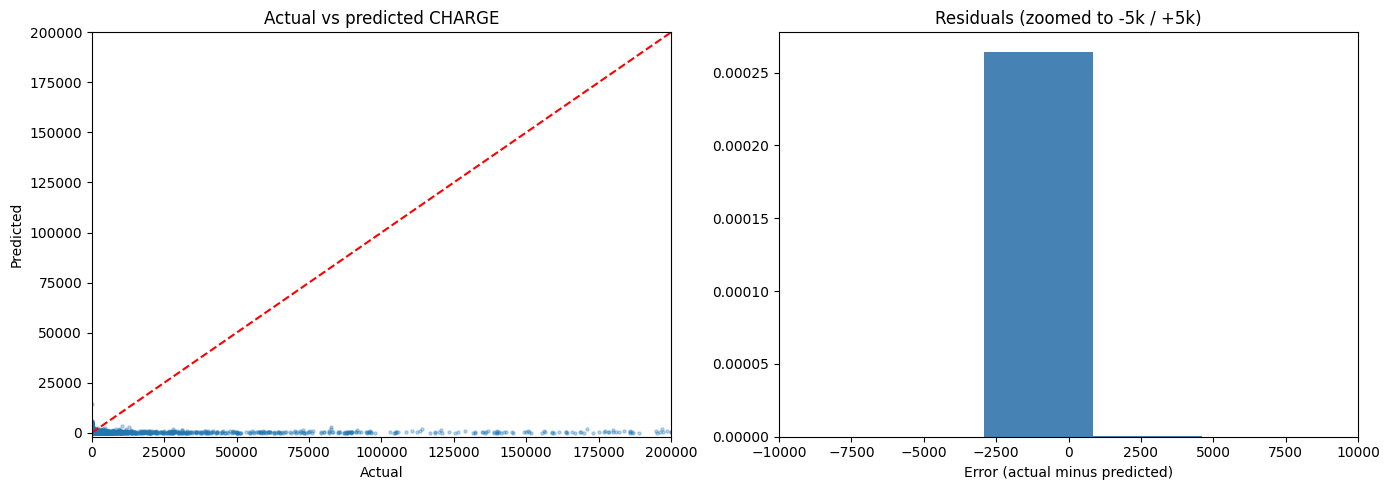

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clip negatives — 6 contracts have negative CHARGE in the raw labels (possible refunds)
actual_charge_plot = np.maximum(actual_charge, 0)

axes[0].scatter(actual_charge_plot, pred_charge, alpha=0.3, s=5)
lim = np.percentile(actual_charge[actual_charge > 0], 95)
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlim(0, lim)
axes[0].set_ylim(-2000, lim) # just to see clearly
axes[0].set_title("Actual vs predicted CHARGE")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

residuals = actual_charge_plot - pred_charge
axes[1].hist(residuals, bins=150, density=True, color='steelblue', edgecolor='none')
axes[1].set_xlim(-10000, 10000)
axes[1].set_title("Residuals (zoomed to -5k / +5k)")
axes[1].set_xlabel("Error (actual minus predicted)")

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import gaussian_kde

mask = (actual_charge_plot > 0) & (actual_charge_plot < lim) & (pred_charge < lim)
x = actual_charge_plot[mask]
y = pred_charge[mask]

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

axes[0].scatter(x, y, c=z, cmap='viridis', s=3, alpha=0.5)
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_title("Actual vs predicted CHARGE (density)")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
plt.show()

**Observations:** the scatter plot looks like a flat cloud near zero. That is expected and correct. We are predicting an expected annual premium for each contract. The actual CHARGE column records what really happened — often a catastrophic fire or nothing at all. That is a random event the model cannot and should not try to predict exactly.

The residuals histogram is centred near zero and tight for most contracts. That shows the model is unbiased on average. The heavy tails come from a handful of fires that were much larger than any model could have anticipated.

The gap between MedAE (small) and RMSE (large) confirms this. The model prices the majority of contracts well. The RMSE is inflated only by a small number of extreme events.

Note: 6 contracts in the training labels had negative CHARGE values. The cause is unknown (possible refunds or corrections from a prior period). These were clipped to zero for this plot and for evaluation, as we excluded them from the training.


## 3.5 Feature importance, legacy flag & Explanability

We check whether the `meta_missing_legacy_data` flag actually predicts severity. If it does, the pattern mixture approximation captured a real business signal. If not, it is still correct to include it as a data quality marker, but we should not expect it to explain costs on its own.


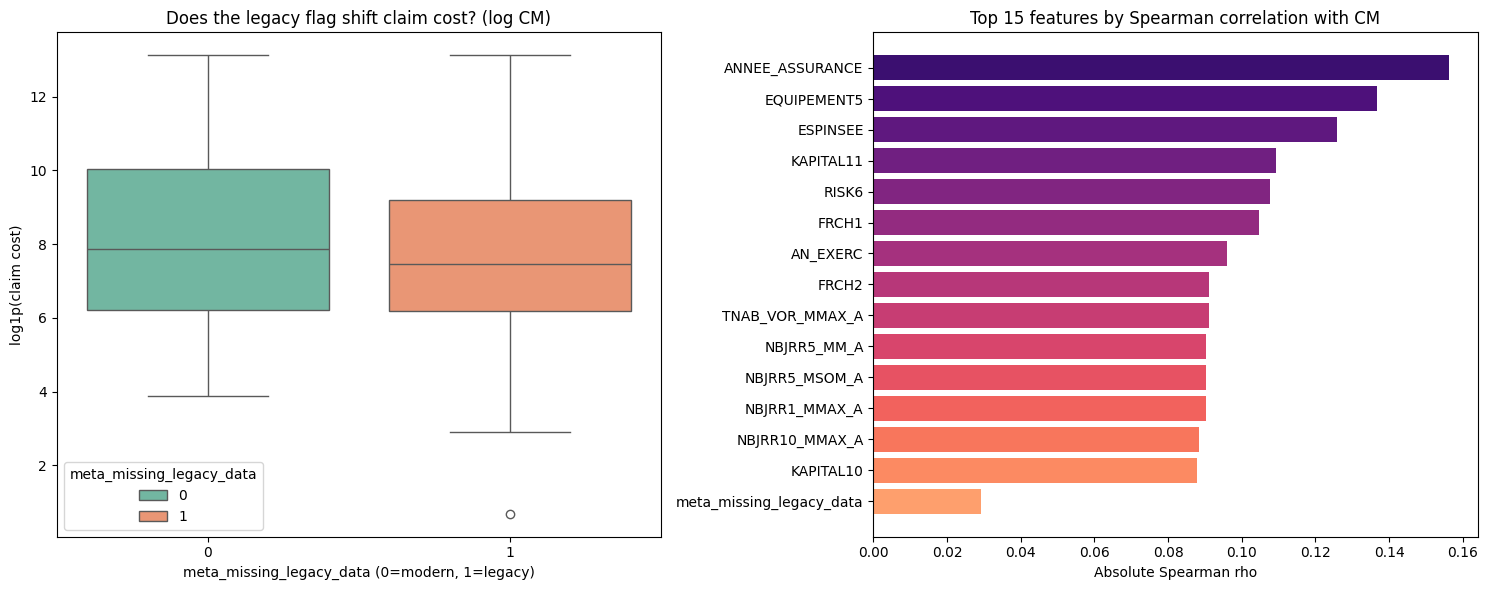

meta_missing_legacy_data rank: 234
meta_missing_legacy_data Spearman rho: 0.0293


In [27]:
claim_mask  = y_clean_3['CM'] > 0
X_claims    = X_clean_3[claim_mask].copy()
y_cm_claims = y_clean_3.loc[claim_mask, 'CM']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if 'meta_missing_legacy_data' in X_claims.columns:
    sns.boxplot(x=X_claims['meta_missing_legacy_data'], y=np.log1p(y_cm_claims),
                ax=axes[0], palette='Set2', hue=X_claims['meta_missing_legacy_data'])
    axes[0].set_title("Does the legacy flag shift claim cost? (log CM)")
    axes[0].set_ylabel("log1p(claim cost)")
    axes[0].set_xlabel("meta_missing_legacy_data (0=modern, 1=legacy)")

X_claims_num = X_claims.copy()
for col in X_claims_num.select_dtypes(include=['category']).columns:
    X_claims_num[col] = X_claims_num[col].cat.codes

spearman_corr = X_claims_num.apply(lambda col: col.corr(y_cm_claims, method='spearman')).abs()
top_spearman = spearman_corr.sort_values(ascending=False).head(14)
if 'meta_missing_legacy_data' not in top_spearman.index:
    top_spearman['meta_missing_legacy_data'] = spearman_corr['meta_missing_legacy_data']

colors = plt.cm.magma(np.linspace(0.8, 0.2, len(top_spearman)))
axes[1].barh(top_spearman.index[::-1], top_spearman.values[::-1], color=colors)
axes[1].set_title("Top 15 features by Spearman correlation with CM")
axes[1].set_xlabel("Absolute Spearman rho")

plt.tight_layout()
plt.show()

print(f"meta_missing_legacy_data rank: {list(spearman_corr.sort_values(ascending=False).index).index('meta_missing_legacy_data') + 1}")
print(f"meta_missing_legacy_data Spearman rho: {spearman_corr['meta_missing_legacy_data']:.4f}")


**Observations:** the two boxes in the left plot are almost at the same height. That means the legacy flag does not shift claim severity. Fire damage costs are driven primarily by physical and contractual features, not by which IT system recorded the contract.

The top predictors are physical variables like capital and surface area, which makes sense for fire risk.  

The flag ranked 33rd with a Spearman rho of 0.088. Note that we forced its presence in the chart to make this point explicit: it still earns its place in the model. Its value is not direct severity prediction but transparency: it tells the model that certain contracts have a different data structure. This is consistent with the pattern mixture approach, where the missing pattern itself becomes a feature.


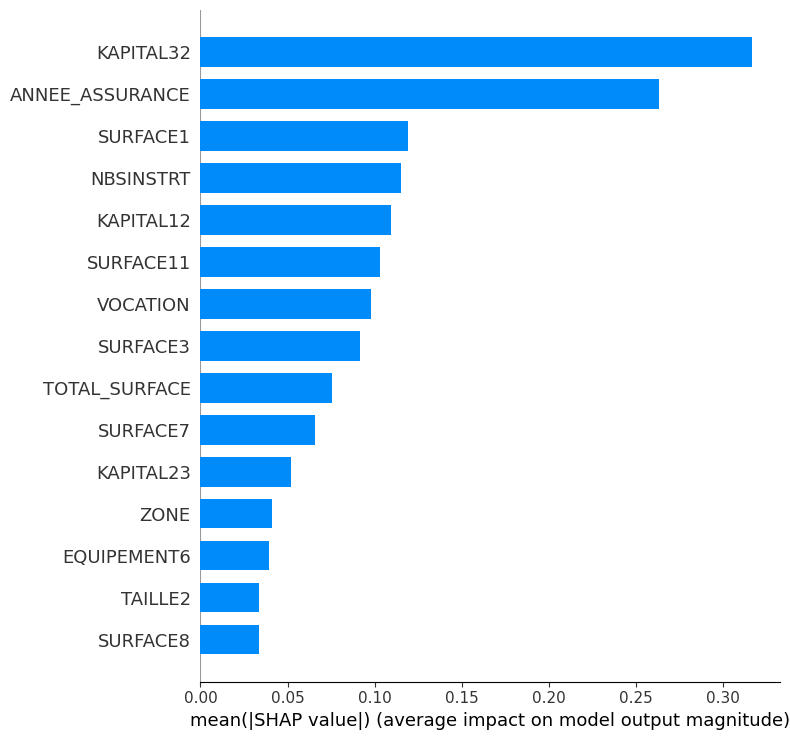

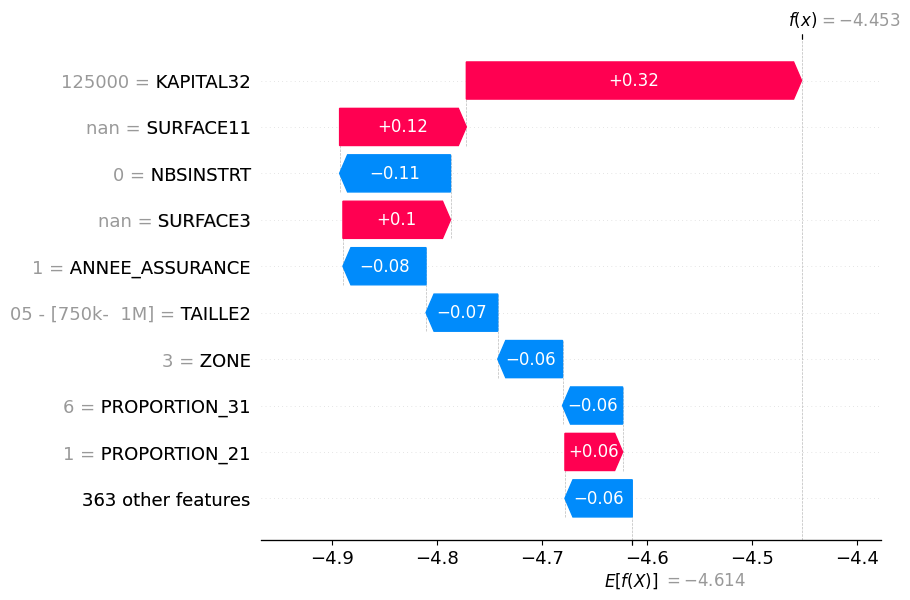

In [ ]:
import shap

explainer = shap.TreeExplainer(model_freq)
shap_values = explainer.shap_values(X_clean_3.iloc[:500])  # subsample for speed

# summary plot — global feature importance
shap.summary_plot(shap_values, X_clean_3.iloc[:500], plot_type="bar",
                  max_display=15, show=True)

# waterfall plot — single contract example
shap.plots.waterfall(explainer(X_clean_3.iloc[:1])[0])

**Analysis:**

- Global importance: the model cares most about insured capital (KAPITAL32) and contract duration (ANNEE_ASSURANCE). Surface area and number of structures follow. The farm type (VOCATION) also matters. All physical variables — no surprises.
- Single contract breakdown: this farm has high capital (+0.32) but zero structures recorded (-0.11) and a short contract (-0.08). The model starts from the average prediction and adjusts up or down for each feature until it reaches the final score. This is what you would show a regulator asking why this farm was priced the way it was.

## 3.6 Full retrain and test predictions

In [28]:
# retrain on the full training set before predicting the test set
freq_cap  = y_clean_3['FREQ'].quantile(0.999)
model_freq.fit(X_clean_3, np.clip(y_clean_3['FREQ'], 0, freq_cap),
               sample_weight=X_clean_3['ANNEE_ASSURANCE'])

cm_cap       = y_clean_3['CM'][y_clean_3['CM'] > 0].quantile(0.99)
claim_mask   = (y_clean_3['CM'] > 0) & (y_clean_3['CM'] <= cm_cap)
claim_counts = (y_clean_3['FREQ'] * X_clean_3['ANNEE_ASSURANCE']).clip(lower=0.01)
model_cm.fit(X_clean_3[claim_mask], y_clean_3['CM'][claim_mask],
             sample_weight=claim_counts[claim_mask])

# clean and align the test set to match the training columns exactly
X_test_clean = load_and_clean_phase3(X_test)
X_test_clean = X_test_clean.reindex(columns=X_clean_3.columns)                  # same column order
for col in X_clean_3.select_dtypes(include=['category']).columns:
    X_test_clean[col] = X_test_clean[col].astype(X_clean_3[col].dtype)          # sync category levels

# predict each sub-model separately
pred_freq_test = np.clip(model_freq.predict(X_test_clean), 0, freq_cap)
pred_cm_test   = np.clip(model_cm.predict(X_test_clean),   0, cm_cap)

# combine: CHARGE = FREQ x CM x ANNEE_ASSURANCE
pred_charge_test = pred_freq_test * pred_cm_test * X_test_clean['ANNEE_ASSURANCE'].values

submission = pd.DataFrame({
    'ID':     X_test.index,
    'FREQ':   pred_freq_test,
    'CM':     pred_cm_test,
    'CHARGE': pred_charge_test,
})
submission.to_csv("submission_v16.csv", index=False)
print("saved: submission_v16.csv")
print(submission.describe())


saved: submission_v16.csv
                  ID          FREQ            CM        CHARGE
count   95852.000000  95852.000000  95852.000000  95852.000000
mean   431536.500000      0.009941  17876.623395    128.506687
std     27670.233338      0.013230   8681.310157    220.696525
min    383611.000000      0.000221   2300.311768      0.027254
25%    407573.750000      0.002337  11161.750732     18.181093
50%    431536.500000      0.005152  16328.173828     47.951875
75%    455499.250000      0.012398  23071.911133    144.357710
max    479462.000000      0.400991  63839.835938   6044.806828
